In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

## Phần 1 Thống kê mô tả và đặc trưng

### Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.


In [2]:
sns.set_theme()
df = sns.load_dataset("iris")
print(df.head(n = 5))
print(df.shape)
print(df.dtypes)


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

In [3]:
num_df = df.select_dtypes(include= "number")
print(num_df.head())


result = pd.DataFrame({
    "Mean:": num_df.mean(), "Median": num_df.median(), "Mode": num_df.mode().iloc[0], "var: ": num_df.var(), "std:": num_df.std(), "min:": num_df.min(), "max: ": num_df.max(), "Q1:": num_df.quantile(0.25), "Q3:": num_df.quantile(0.75), "IQR:" : num_df.quantile(0.75) - num_df.quantile(0.25)
})
print(result)

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
                 Mean:  Median  Mode     var:       std:  min:  max:   Q1:  \
sepal_length  5.843333    5.80   5.0  0.685694  0.828066   4.3    7.9  5.1   
sepal_width   3.057333    3.00   3.0  0.189979  0.435866   2.0    4.4  2.8   
petal_length  3.758000    4.35   1.4  3.116278  1.765298   1.0    6.9  1.6   
petal_width   1.199333    1.30   0.2  0.581006  0.762238   0.1    2.5  0.3   

              Q3:  IQR:  
sepal_length  6.4   1.3  
sepal_width   3.3   0.5  
petal_length  5.1   3.5  
petal_width   1.8   1.5  


# Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.


In [4]:
mean_gb = df.groupby("species").mean()

std_gb = df.groupby("species").std()

print("Mean group by species : \n",mean_gb)
print("Std group by species: \n", std_gb)

Mean group by species : 
             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
Std group by species: 
             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


*Xét về trung bình:*

setosa là loài có sepal_length, petal_length, petal_lenght nhỏ nhất trong ba loài nhưng lại có sepal_width lớn nhất.

Ngược lại virginca tuy sepal width nhỏ hơn setosa nhưng các thông số còn lại đề có giá trị lớn nhất trong ba loài, versicolor có các giá trị trung bình khá gần với trung bình tổng thể.

*Xét về độ lệch chuẩn:*

Các giá trị của độ lệch chuẩn tương đối nhỏ, cho thấy dữ liệu phân bố tập trung xung quanh quanh giá trị trung bình, ít biến động

setosa có độ lệch chuẩn khá nhỏ ở hầu hết các chỉ số cho thấy loài này thường có ngoại hình khá giống nhau trong khi virginica lại có độ lệch chuẩn lớn nhất thể hiện giữa các bông hoa cùng loài có thể có kích thước và hình dáng khác nhau

## Phân phối xác suất

### Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?


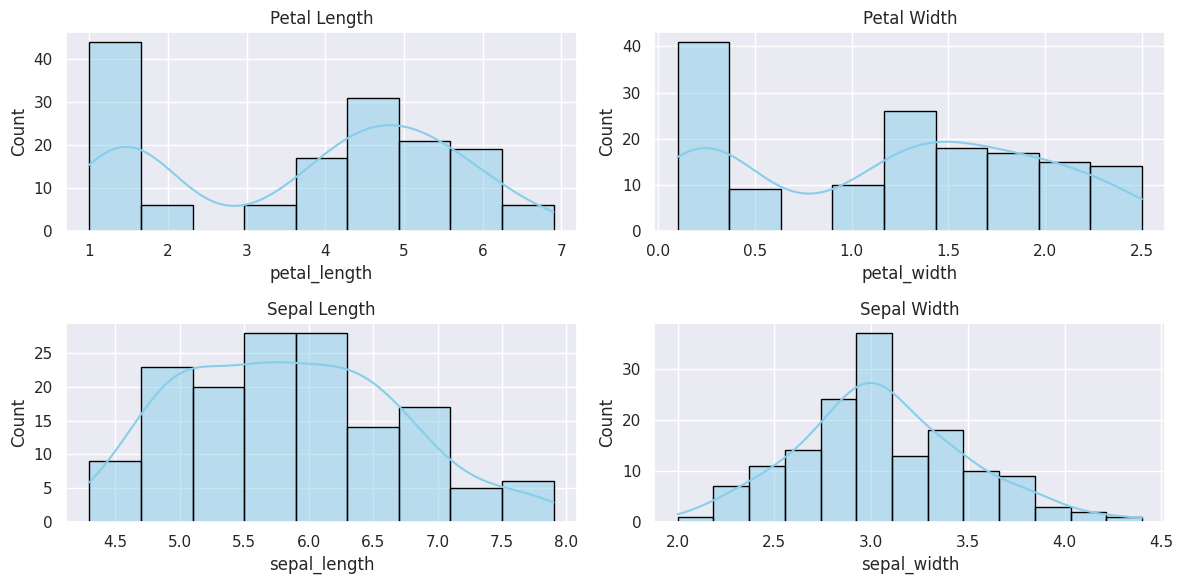

In [5]:
fig, axes = plt.subplots(2,2,figsize = (12,6))
color = 'skyblue'
edgecolor = 'black'
line_kde = 'red'
sns.histplot(df['petal_length'],kde = True, ax = axes[0][0], color=color, edgecolor = edgecolor, line_kws={'color':line_kde})
axes[0][0].set_title('Petal Length')

sns.histplot(df['petal_width'],kde = True, ax = axes[0][1], color=color, edgecolor = edgecolor, line_kws={'color':line_kde})
axes[0][1].set_title('Petal Width')

sns.histplot(df['sepal_length'],kde = True, ax = axes[1][0], color=color, edgecolor = edgecolor, line_kws={'color':line_kde})
axes[1][0].set_title('Sepal Length')

sns.histplot(df['sepal_width'],kde = True, ax = axes[1][1], color=color, edgecolor = edgecolor, line_kws={'color':line_kde})
axes[1][1].set_title('Sepal Width')

plt.tight_layout()
plt.show()

Dựa vào 4 đồ thị trên có thể thấy đồ thị histogram của petal length và petal width là đồ thị nhiều đỉnh
Đồ thị của sepal width là đồ thị gần phân phối chuẩn và đồ thị sepal length hơi lệch phải.

### Vẽ boxplot từng biến theo nhóm species để so sánh phân phối giữa các loài

<Axes: xlabel='species', ylabel='sepal_width'>

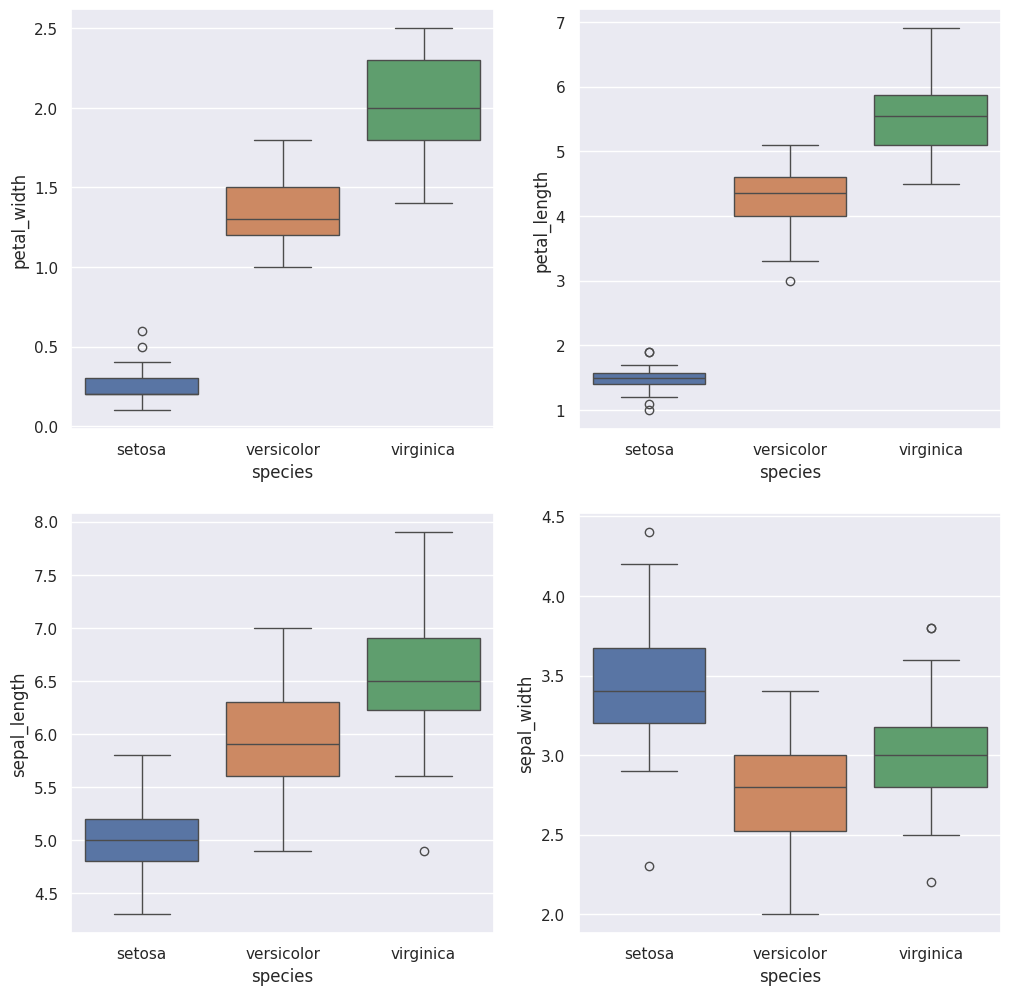

In [6]:
fig, axes = plt.subplots(2,2,figsize=(12,12))

sns.boxplot(df,x= 'species', y = 'petal_width', hue = 'species',ax = axes[0][0])
sns.boxplot(df,x= 'species', y = 'petal_length', hue = 'species',ax = axes[0][1])
sns.boxplot(df,x= 'species', y = 'sepal_length', hue = 'species',ax = axes[1][0])
sns.boxplot(df,x= 'species', y = 'sepal_width', hue = 'species',ax = axes[1][1])

Có thể thấy petal width và petal length giữa các loài có boxplot tách biệt nhau rõ ràng

Sepal length và sepal width có khả năng phân biệt thấp hơn vì các boxplot có xu hướng chồng lên nhau.


### Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp.


3.0573333333333337 0.435866284936698
(150,)


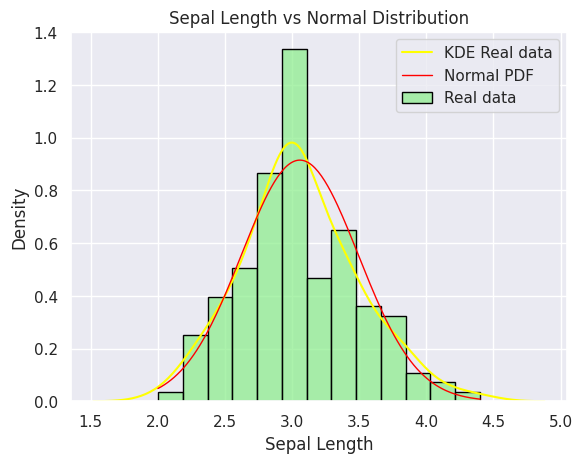

In [24]:
data = df['sepal_width']
mean_data = data.mean()
std_data = data.std()
print(mean_data, std_data)
sns.histplot(data,color = 'lightgreen', edgecolor = 'black', stat='density', label = 'Real data')
xs = np.linspace(data.min(),data.max(),200)
pdf = norm.pdf(xs,mean_data,std_data)
sns.kdeplot(data,color = 'yellow',label = 'KDE Real data')
plt.plot(xs,pdf, color = 'red', linewidth = 1, label = 'Normal PDF')
plt.title("Sepal Length vs Normal Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.legend()
simulate_data = np.random.normal(mean_data,std_data,len(data))

print(simulate_data.shape)

Dữ liệu sepal_width có dạng gần phân phối chuẩn

## Phần 3 — Phân tích đa biến & tương quan



### Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số

In [25]:
cov_matrix = num_df.cov()
cor_matrix = num_df.corr()

print("Covariance Matrix:")
print(cov_matrix)

print("Correlation Matrix:")
print(cor_matrix)

Covariance Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


### Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

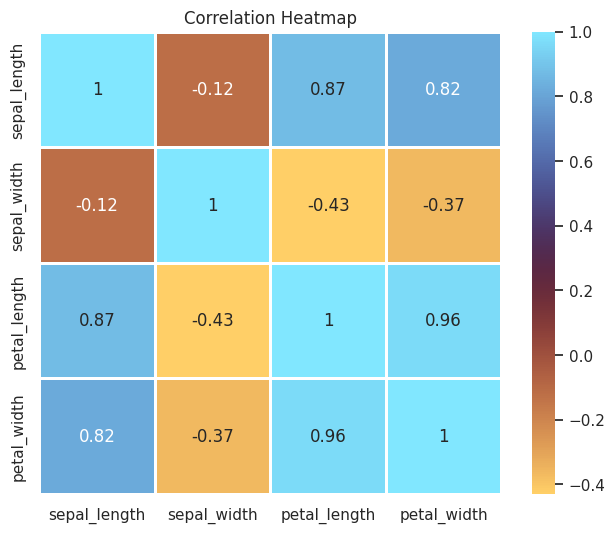

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(cor_matrix, annot=True,cmap = "managua",linewidths = 1,square=True)
plt.title("Correlation Heatmap")
plt.show()

Giữa petal length và petal width có hệ số tương quan cao r = 0.96
Giữa petal length và sepal length có hệ số tương quan cao r = 87
Giữa petal width và sepal length có hệ số tương quan cao r = 82


Nếu các cặp biến này được sử dụng trong mô hình hồi quy sẽ có thể xảy ra hiện tượng đa cộng tuyến

### Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

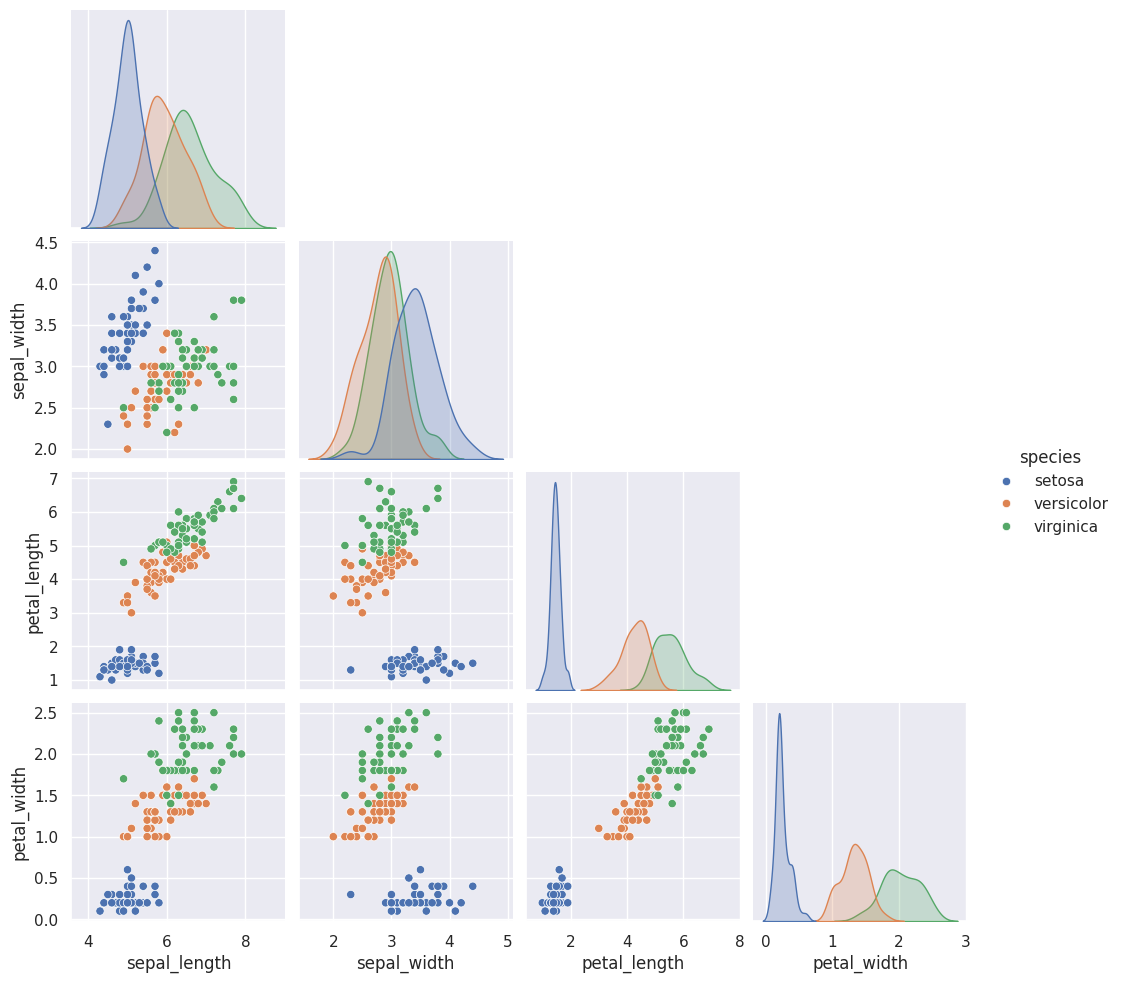

In [37]:
sns.pairplot(df, hue='species',corner=True )

Petal length và petal width có mối tương quan tuyến tính cao
Sepal length tương quan cao với petal width
Sepal width tương quan yếu với các biến còn lại

## Phần 4 — Xác suất & Định lý Bayes

### Viết code tính xác suất hậu nghiệm P(B | +) bằng định lý Bayes và in kết quả.

In [40]:
P_B = 0.01
P_B_ = 0.99

P_pos_B = 0.99
P_pos_not_B = 0.05


P_B_pos = (P_pos_B*P_B)/(P_pos_B*P_B + P_pos_not_B*P_B_)
print(P_B_pos)

0.16666666666666669


### Khảo sát: vẽ đồ thị P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

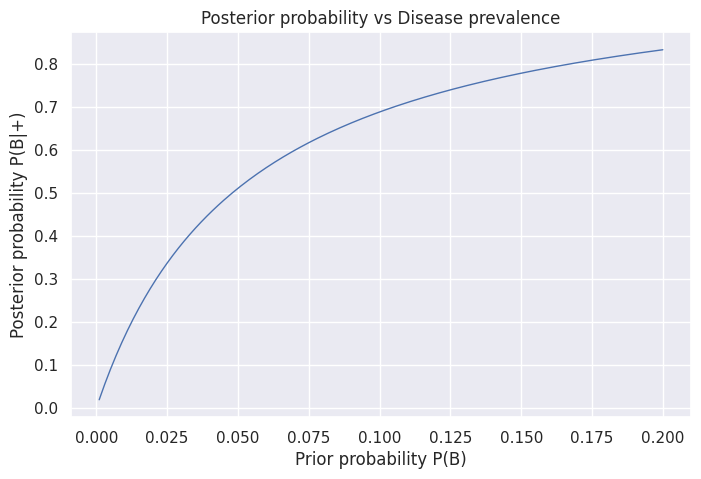

In [42]:
P_B = np.linspace(0.001,0.2,200)
P_B_ = 1 - P_B

P_pos_B = 0.99
P_pos_not_B = 0.05


P_B_pos = (P_pos_B*P_B)/(P_pos_B*P_B + P_pos_not_B*P_B_)


plt.figure(figsize=(8,5))

plt.plot(P_B, P_B_pos, linewidth=1)
plt.xlabel("Prior probability P(B)")
plt.ylabel("Posterior probability P(B|+)")
plt.title("Posterior probability vs Disease prevalence")

plt.grid(True)

plt.show()

Khi tỷ lệ mắc bệnh hiếm dẫn đến tỷ lệ dương tính giả cao
Ví dụ khi tỷ lệ mắc bệnh là $0.01$ => dẫn đến tỷ lệ dương tính giả sẽ là $0.05 \times0.99$ sẽ lớn hơn so với khi tỷ lệ mắc bệnh là $0.2$ => tỷ lệ dương tính giả là $0.05\times0.8$

Tỷ lệ dương tính giả càng lớn dẫn đến xác suất chính xác càng nhỏ.

